#  Data Preprocessing



Data preprocessing consists of a broad set of techniques for cleaning, selecting, and transforming data to improve data mining analysis. Read the step-by-step instructions below carefully. To execute the code, click on the corresponding cell and press the SHIFT-ENTER keys simultaneously.

To do the preprocessing we are going to follow these steps: 

    Load data:
        Separating the target from the data
        Separating the test from the train
    Clean data
        look data
        Differentiate Between Categorical and Numerical Variables
        Visualize the data
    Missing data
        Delete all
        Encode
        Imputing data->Average, Median, mode(categorical)
        Duplicated_Data
    Data transformation
        Normalization
        Standarization
        Discretizacion
        Moving from categorical data to numerical data--> By hard, LabelEnc, One-Hot encoding, Bunary encoding
     Fetured selection/Exytraction
         Feature selection--> Seleccion de caracteristicas
                 .
                 .
                 .
            

#  Load Data

In [1]:
import pandas as pd

data = pd.read_csv("archive_2/IBEX-1994-2020.csv")
"""
# Ordena el DataFrame por la columna 'Date' para asegurarte de que las fechas estén en orden ascendente
data = data.sort_values(by='Date')

# Supongamos que datuak es tu DataFrame original
# Asegurémonos de que la columna 'Date' esté en formato datetime
data['Date'] = pd.to_datetime(data['Date'])

# Crea un rango de fechas que cubra desde la fecha mínima hasta la fecha máxima
rango_fechas = pd.date_range(start='1994-1-1', end=data['Date'].max(), freq='D')  # 'B' para días hábiles

# Reindexa el DataFrame usando el nuevo rango de fechas
data = data.set_index('Date').reindex(rango_fechas).reset_index()
data = data.fillna(0).reset_index(drop=True)

this is the madafakin remix

"""
# Imprime el DataFrame actualizado
print(data)


            Date         Open         High          Low        Close  \
0     1994-01-03  3615.199951  3654.699951  3581.000000  3654.500000   
1     1994-01-04  3654.500000  3675.500000  3625.100098  3630.300049   
2     1994-01-05  3625.199951  3625.199951  3583.399902  3621.199951   
3     1994-01-07  3621.199951  3644.399902  3598.699951  3636.399902   
4     1994-01-10  3655.199951  3678.199951  3655.199951  3660.600098   
...          ...          ...          ...          ...          ...   
6821  2020-12-18  8114.299805  8159.399902  8036.700195  8037.399902   
6822  2020-12-21  7860.899902  7872.299805  7663.500000  7789.799805   
6823  2020-12-22  7822.000000  7942.399902  7818.000000  7934.200195   
6824  2020-12-23  7948.799805  8084.200195  7940.000000  8073.600098   
6825  2020-12-24  8101.200195  8112.399902  8073.299805  8111.500000   

         AdjClose     Volume  
0     3654.496338          0  
1     3630.296387          0  
2     3621.196289          0  
3     3636.

In [2]:
data.head()

,Date,Open,High,Low,Close,AdjClose,Volume
0,1994-01-03,3615.199951,3654.699951,3581.000000,3654.500000,3654.496338,0
1,1994-01-04,3654.500000,3675.500000,3625.100098,3630.300049,3630.296387,0
2,1994-01-05,3625.199951,3625.199951,3583.399902,3621.199951,3621.196289,0
3,1994-01-07,3621.199951,3644.399902,3598.699951,3636.399902,3636.396240,0
4,1994-01-10,3655.199951,3678.199951,3655.199951,3660.600098,3660.596436,0


In [3]:
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'AdjClose', 'Volume'], dtype='object')

# Datuen bisualizazia

Hau ez da oso beharrezkoa egitea.

# Add missing data 

In [4]:
numerical_columns = ['Open', 'High', 'Low', 'Close', 'AdjClose', 'Volume']
categorical_columns = ['Date']
all_columns = numerical_columns + categorical_columns

data_numeric = data[numerical_columns]
data_categorical = data[categorical_columns]


## Imputing data

Mediana erabiliko dugu, ez baita hain hauskorra muturreko balioei dagokienez, eta, beraz, askoz ere adierazgarriagoa da.


In [5]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy = "median")

imp.fit(data_numeric)
numpyarray=imp.transform(data_numeric)
print(numpyarray)
data_new=pd.DataFrame(numpyarray,columns=data_numeric.columns)
print(data_new.isnull().sum())
data_new


[[3.61519995e+03 3.65469995e+03 3.58100000e+03 3.65450000e+03
  3.65449634e+03 0.00000000e+00]
 [3.65450000e+03 3.67550000e+03 3.62510010e+03 3.63030005e+03
  3.63029639e+03 0.00000000e+00]
 [3.62519995e+03 3.62519995e+03 3.58339990e+03 3.62119995e+03
  3.62119629e+03 0.00000000e+00]
 ...
 [7.82200000e+03 7.94239990e+03 7.81800000e+03 7.93420020e+03
  7.93420020e+03 1.87112500e+08]
 [7.94879980e+03 8.08420020e+03 7.94000000e+03 8.07360010e+03
  8.07360010e+03 1.83108500e+08]
 [8.10120020e+03 8.11239990e+03 8.07329980e+03 8.11150000e+03
  8.11150000e+03 8.37082000e+07]]
Open        0
High        0
Low         0
Close       0
AdjClose    0
Volume      0
dtype: int64


,Open,High,Low,Close,AdjClose,Volume
0,3615.199951,3654.699951,3581.000000,3654.500000,3654.496338,0.0
1,3654.500000,3675.500000,3625.100098,3630.300049,3630.296387,0.0
2,3625.199951,3625.199951,3583.399902,3621.199951,3621.196289,0.0
3,3621.199951,3644.399902,3598.699951,3636.399902,3636.396240,0.0
4,3655.199951,3678.199951,3655.199951,3660.600098,3660.596436,0.0
...,...,...,...,...,...,...
6821,8114.299805,8159.399902,8036.700195,8037.399902,8037.399902,355173100.0
6822,7860.899902,7872.299805,7663.500000,7789.799805,7789.799805,339116800.0
6823,7822.000000,7942.399902,7818.000000,7934.200195,7934.200195,187112500.0
6824,7948.799805,8084.200195,7940.000000,8073.600098,8073.600098,183108500.0


### We need a function that takes care of the other dates to simulate if the market is going up or down

In [6]:
## Function of to calculate the missing values
print(data.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'AdjClose', 'Volume'], dtype='object')


C:\Users\andon\anaconda3\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


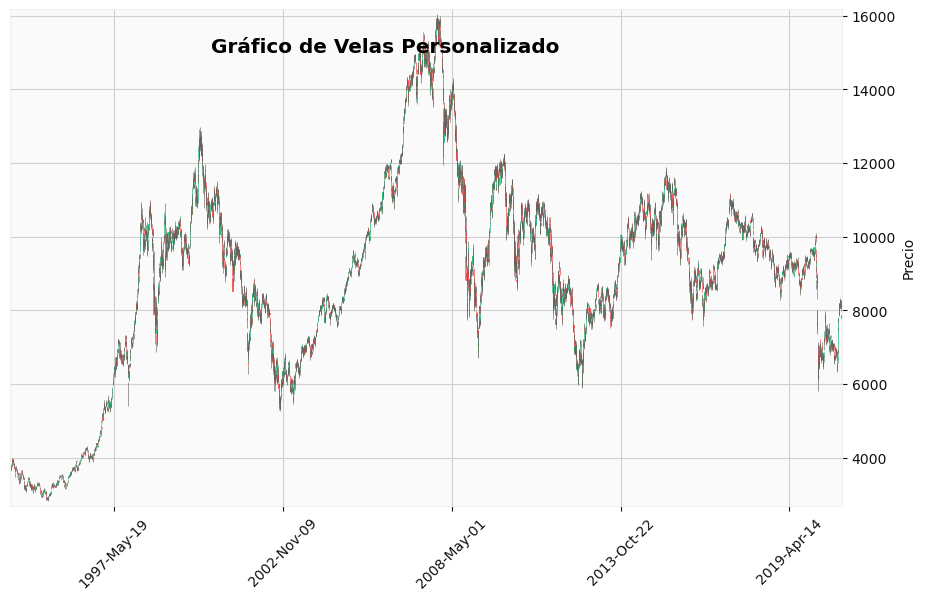

           Date         Open         High          Low        Close  \
0    1994-01-03  3615.199951  3654.699951  3581.000000  3654.500000   
1    1994-01-04  3654.500000  3675.500000  3625.100098  3630.300049   
2    1994-01-05  3625.199951  3625.199951  3583.399902  3621.199951   
3    1994-01-07  3621.199951  3644.399902  3598.699951  3636.399902   
4    1994-01-10  3655.199951  3678.199951  3655.199951  3660.600098   
...         ...          ...          ...          ...          ...   
6821 2020-12-18  8114.299805  8159.399902  8036.700195  8037.399902   
6822 2020-12-21  7860.899902  7872.299805  7663.500000  7789.799805   
6823 2020-12-22  7822.000000  7942.399902  7818.000000  7934.200195   
6824 2020-12-23  7948.799805  8084.200195  7940.000000  8073.600098   
6825 2020-12-24  8101.200195  8112.399902  8073.299805  8111.500000   

         AdjClose     Volume  
0     3654.496338          0  
1     3630.296387          0  
2     3621.196289          0  
3     3636.396240      

In [7]:
import pandas as pd
import mplfinance as mpf

# Asegurémonos de que la columna 'Date' esté en formato datetime y establezcamos como índice
data['Date'] = pd.to_datetime(data['Date'])
data.set_index('Date', inplace=True)

# Personalizar la apariencia del gráfico
kwargs = dict(
    type='candle',  # Tipo de gráfico de velas
    style='yahoo',  # Estilo del gráfico de velas
    title='Gráfico de Velas Personalizado',  # Título del gráfico
    ylabel='Precio',  # Etiqueta del eje y
    ylabel_lower='Volumen',  # Etiqueta del eje y en la parte inferior (para el volumen)
    show_nontrading=True,  # Mostrar días no comerciales
    tight_layout=True,  # Ajustar el diseño del gráfico
    figratio=(5, 3),  # Relación de aspecto de la figura
)

# Crear un gráfico de velas con las configuraciones personalizadas
mpf.plot(data, **kwargs)

# Mostrar el gráfico
mpf.show()

# Resetear el índice para que 'Date' vuelva a ser una columna
data.reset_index(inplace=True)

# Imprimir el DataFrame después de resetear el índice
print(data)

# Correlation

Korrelazioa zein den ikusiko dugu datuen artean. Horrela kendu izan ahalko ditugu.


In [8]:
corr = data_numeric.corr()
corr.style.background_gradient(cmap='coolwarm')
print(data.columns)

Index(['Date', 'Open', 'High', 'Low', 'Close', 'AdjClose', 'Volume'], dtype='object')


# Data Transformation

## Normalization 

In [9]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
# Create a MinMaxScaler
MMsc = MinMaxScaler()


# Normalize all numerical columns
data[numerical_columns] = MMsc.fit_transform(data[numerical_columns])

# Now, all numerical columns have been normalized in the 'fifa_dataset'
data.head(20)


,Date,Open,High,Low,Close,AdjClose,Volume
0,1994-01-03,0.057111,0.059059,0.057338,0.060349,0.060349,0.0
1,1994-01-04,0.060103,0.060639,0.060721,0.058499,0.058499,0.0
2,1994-01-05,0.057872,0.056818,0.057522,0.057803,0.057803,0.0
3,1994-01-07,0.057568,0.058277,0.058696,0.058965,0.058965,0.0
4,1994-01-10,0.060156,0.060844,0.063030,0.060815,0.060815,0.0
5,1994-01-11,0.062022,0.063450,0.064910,0.064775,0.064775,0.0
6,1994-01-12,0.064504,0.063435,0.064618,0.062306,0.062306,0.0
7,1994-01-13,0.062052,0.062364,0.064196,0.062360,0.062360,0.0
8,1994-01-14,0.062106,0.065342,0.063621,0.066610,0.066610,0.0
9,1994-01-17,0.066339,0.068829,0.068301,0.066052,0.066052,0.0


In [10]:
data.head()


,Date,Open,High,Low,Close,AdjClose,Volume
0,1994-01-03,0.057111,0.059059,0.057338,0.060349,0.060349,0.0
1,1994-01-04,0.060103,0.060639,0.060721,0.058499,0.058499,0.0
2,1994-01-05,0.057872,0.056818,0.057522,0.057803,0.057803,0.0
3,1994-01-07,0.057568,0.058277,0.058696,0.058965,0.058965,0.0
4,1994-01-10,0.060156,0.060844,0.063030,0.060815,0.060815,0.0


## Modeling With Forecasting

### Using Prophet model

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from prophet import Prophet

from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')
plt.style.use('fivethirtyeight')


## MAPE mean absolute percent error, 
def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100   

data.head()


,Date,Open,High,Low,Close,AdjClose,Volume
0,1994-01-03,0.057111,0.059059,0.057338,0.060349,0.060349,0.0
1,1994-01-04,0.060103,0.060639,0.060721,0.058499,0.058499,0.0
2,1994-01-05,0.057872,0.056818,0.057522,0.057803,0.057803,0.0
3,1994-01-07,0.057568,0.058277,0.058696,0.058965,0.058965,0.0
4,1994-01-10,0.060156,0.060844,0.063030,0.060815,0.060815,0.0


### See the data

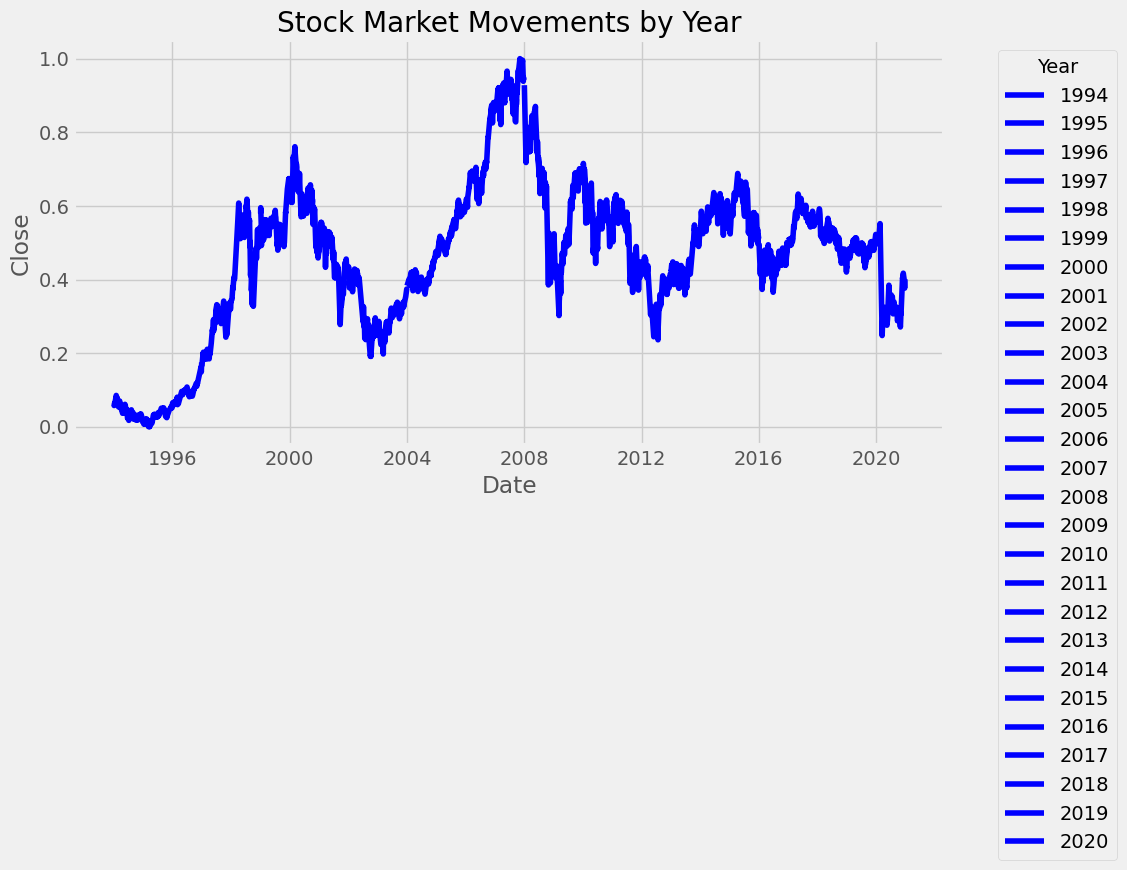

In [12]:
# Group the data by year
data_por_anio = data.groupby(data['Date'].dt.year)

# Create the chart
plt.figure(figsize=(10, 5))

# Use only one color (blue in this case).
color = 'blue'

for anio, grupo in data_por_anio:
    plt.plot(grupo['Date'], grupo['Close'], label=str(anio), color=color)

plt.title('Stock Market Movements by Year')
plt.xlabel('Date')
plt.ylabel('Close')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


## Time Series Features

In [13]:
import pandas as pd
from pandas.api.types import CategoricalDtype

# Supongamos que 'df' es tu DataFrame con los datos proporcionados
cat_type = CategoricalDtype(categories=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], ordered=True)

def create_features(df, label=None):
    """
    Creates time series features from datetime index.
    """
    df = df.copy()
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['weekday'] = df['Date'].dt.day_name()
    df['weekday'] = df['weekday'].astype(cat_type)
    df['quarter'] = df['Date'].dt.quarter
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['dayofyear'] = df['Date'].dt.dayofyear
    df['dayofmonth'] = df['Date'].dt.day
    df['date_offset'] = (df['Date'].dt.month * 100 + df['Date'].dt.day - 320) % 1300

    df['season'] = pd.cut(df['date_offset'], [0, 300, 602, 900, 1300],
                          labels=['Spring', 'Summer', 'Fall', 'Winter']
                   )
    X = df[['dayofweek', 'quarter', 'month', 'year',
           'dayofyear', 'dayofmonth','season']]
    if label:
        y = df[label]
        return X, y
    return X

# Utiliza tu DataFrame 'data' en lugar de 'pjme'
X, y = create_features(data, label='AdjClose')  # Ajusta 'Close' según tu columna de interés
features_and_target = pd.concat([X, y], axis=1)

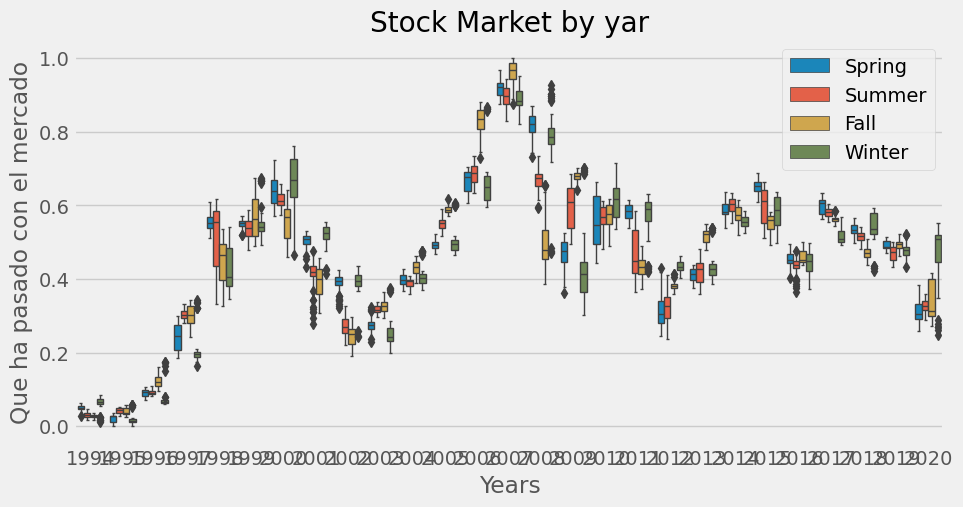

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=features_and_target.dropna(),
            x='year',
            y='AdjClose',
            hue='season',
            ax=ax,
            linewidth=1)
ax.set_title('Stock Market by yar')
ax.set_xlabel('Years')
ax.set_ylabel('Que ha pasado con el mercado')
ax.legend(bbox_to_anchor=(1, 1))
plt.show()

In [15]:
print(data.columns)
data.head() 


Index(['Date', 'Open', 'High', 'Low', 'Close', 'AdjClose', 'Volume'], dtype='object')


,Date,Open,High,Low,Close,AdjClose,Volume
0,1994-01-03,0.057111,0.059059,0.057338,0.060349,0.060349,0.0
1,1994-01-04,0.060103,0.060639,0.060721,0.058499,0.058499,0.0
2,1994-01-05,0.057872,0.056818,0.057522,0.057803,0.057803,0.0
3,1994-01-07,0.057568,0.058277,0.058696,0.058965,0.058965,0.0
4,1994-01-10,0.060156,0.060844,0.063030,0.060815,0.060815,0.0


## Train / Test Split


Index(['Date', 'Open', 'High', 'Low', 'Close', 'AdjClose', 'Volume'], dtype='object')


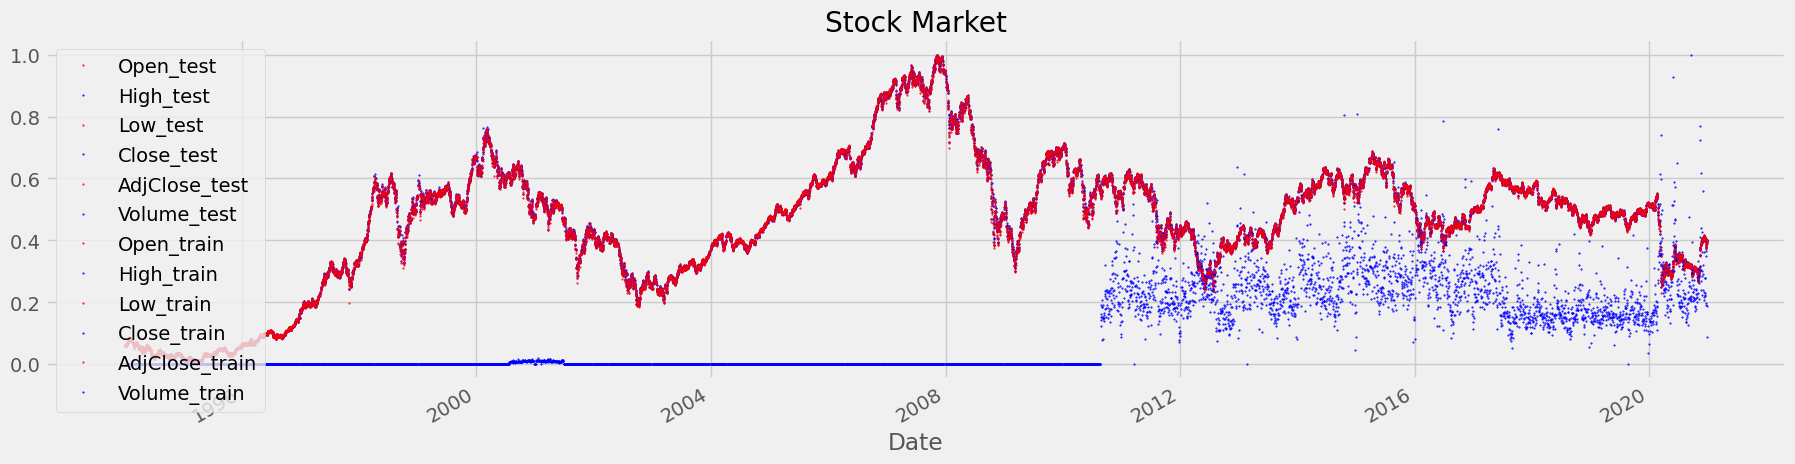

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

print(data.columns)

data.head()

# Asegúrate de que la columna 'Date' sea de tipo datetime
data['Date'] = pd.to_datetime(data['Date'])

# Configura la columna 'Date' como índice del DataFrame
data.set_index('Date', inplace=True)

# Define la fecha de separación
split_date = pd.to_datetime('2017-01-03')


# Filtra los datos para crear conjuntos de entrenamiento y prueba
data_train = data[data.index <= split_date].copy()
data_test = data[data.index > split_date].copy()

# Grafica los conjuntos de entrenamiento y prueba para ver la división
data_test \
    .rename(columns={'Open': 'Open_test', 'High': 'High_test', 'Low': 'Low_test', 'Close': 'Close_test', 'AdjClose': 'AdjClose_test', 'Volume': 'Volume_test', 'Change': 'Change_test'}) \
    .join(data_train.rename(columns={'Open': 'Open_train', 'High': 'High_train', 'Low': 'Low_train', 'Close': 'Close_train', 'AdjClose': 'AdjClose_train', 'Volume': 'Volume_train', 'Change': 'Change_train'}),
          how='outer') \
    .plot(figsize=(20, 5), title='Stock Market', style='.', ms=1, color=['red', 'blue'])

ax.xaxis.set_major_locator(plt.matplotlib.dates.YearLocator(1))
plt.show()


In [17]:
split_date = '2017-01-03'
data_train = data.loc[data.index <= split_date].copy()
data_test = data.loc[data.index > split_date].copy()


"""
 Plot train and test so you can see where we have split
 data_test \
     .rename(columns={'PJME_MW': 'TEST SET'}) \
    .join(data_train.rename(columns={'PJME_MW': 'TRAINING SET'}),
           how='outer') \
  .plot(figsize=(10, 5), title='PJM East', style='.', ms=1)
 plt.show()
 """

"\n Plot train and test so you can see where we have split\n data_test      .rename(columns={'PJME_MW': 'TEST SET'})     .join(data_train.rename(columns={'PJME_MW': 'TRAINING SET'}),\n           how='outer')   .plot(figsize=(10, 5), title='PJM East', style='.', ms=1)\n plt.show()\n "

## Simple Prophet Model


In [18]:
# Format data for prophet model using ds and y
data_train_prophet = data_train.reset_index() \
.rename(columns={'Date':'ds', 'AdjClose':'y'})   

In [19]:
%%time
model = Prophet()
## We could change variables of the model to get a better prediction
model.fit(data_train_prophet)


12:16:56 - cmdstanpy - INFO - Chain [1] start processing
12:16:58 - cmdstanpy - INFO - Chain [1] done processing


CPU times: total: 938 ms
Wall time: 3.07 s


In [20]:
# Predict on test set with model
data_test_prophet = data_test.reset_index() \
    .rename(columns={'Date':'ds',
                     'Close':'y'})

data_test_fcst = model.predict(data_test_prophet)

In [21]:
data_test_fcst.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2017-01-04,0.568716,0.493538,0.649468,0.568716,0.568716,0.003601,0.003601,0.003601,-0.003887,-0.003887,-0.003887,0.007487,0.007487,0.007487,0.0,0.0,0.0,0.572317
1,2017-01-05,0.568803,0.491492,0.649876,0.568803,0.568803,0.003639,0.003639,0.003639,-0.004128,-0.004128,-0.004128,0.007767,0.007767,0.007767,0.0,0.0,0.0,0.572442
2,2017-01-06,0.568889,0.496525,0.652669,0.568889,0.568889,0.004347,0.004347,0.004347,-0.003657,-0.003657,-0.003657,0.008004,0.008004,0.008004,0.0,0.0,0.0,0.573236
3,2017-01-09,0.569148,0.498019,0.662909,0.569148,0.569148,0.004582,0.004582,0.004582,-0.003825,-0.003825,-0.003825,0.008407,0.008407,0.008407,0.0,0.0,0.0,0.573731
4,2017-01-10,0.569235,0.499758,0.652794,0.569235,0.569235,0.004850,0.004850,0.004850,-0.003578,-0.003578,-0.003578,0.008427,0.008427,0.008427,0.0,0.0,0.0,0.574085


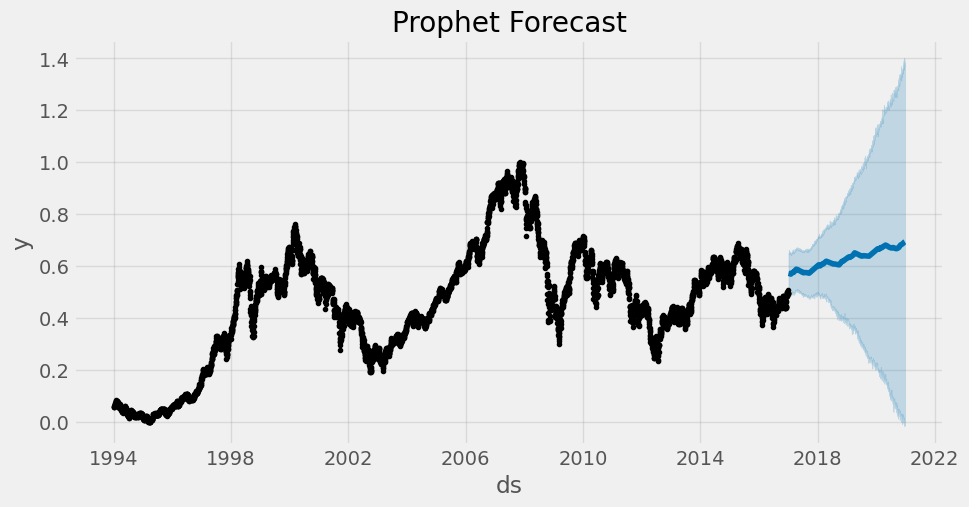

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
fig = model.plot(data_test_fcst, ax=ax)
ax.set_title('Prophet Forecast')
plt.show()

## Compare Forecast to Actuals


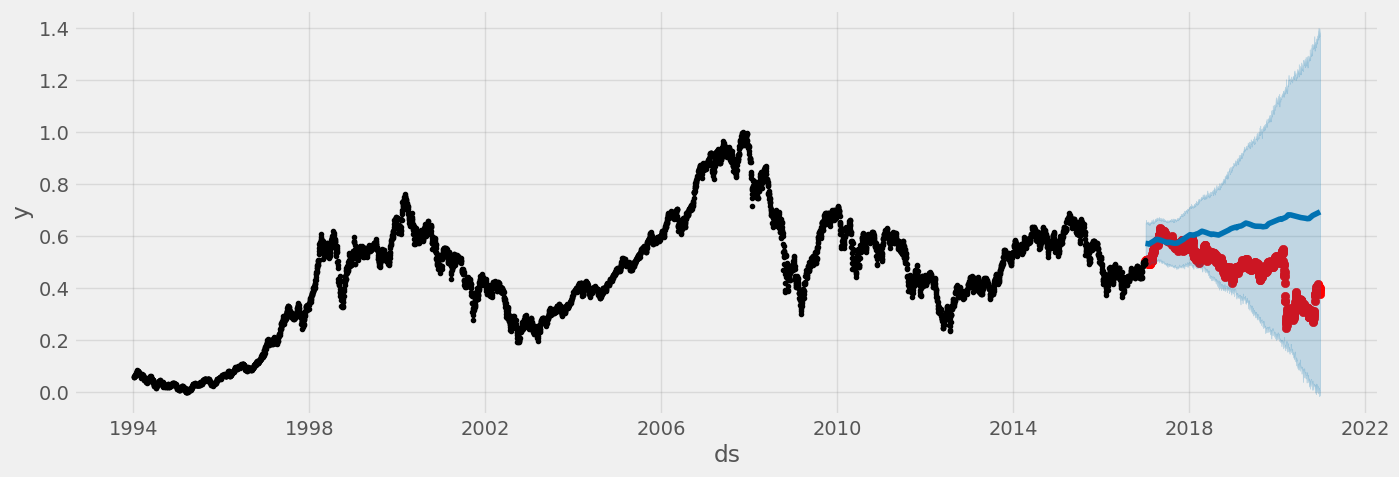

In [23]:
# Plot the forecast with the actuals
f, ax = plt.subplots(figsize=(15, 5))
ax.scatter(data_test.index, data_test['Close'], color='r')
fig = model.plot(data_test_fcst, ax=ax)

ConversionError: Failed to convert value(s) to axis units: '01-01-2019'

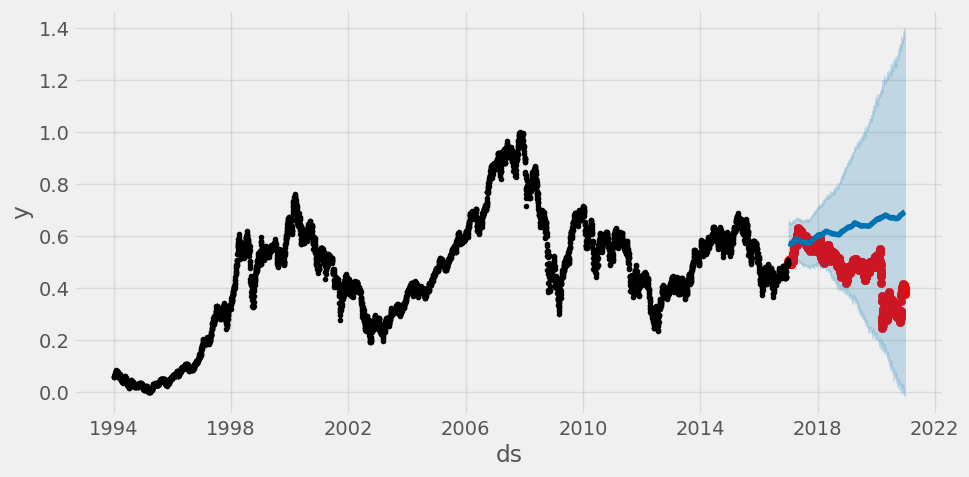

In [24]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(data_test.index, data_test['Close'], color='r')
fig = model.plot(data_test_fcst, ax=ax)
ax.set_xbound(lower='01-01-2019',
              upper='02-01-2019')
ax.set_ylim(0, 60000)
plot = plt.suptitle('January 2015 Forecast vs Actuals')

## Error metrics


In [ ]:
np.sqrt(mean_squared_error(y_true=data_test['Close'],
                   y_pred=data_test_fcst['yhat']))

In [ ]:
mean_absolute_error(y_true=data_test['Close'],
                   y_pred=data_test_fcst['yhat'])

In [ ]:
mean_absolute_percentage_error(y_true=pjme_test['Close'],
                   y_pred=data_test_fcst['yhat'])